<a href="https://colab.research.google.com/github/tatyanayuriy/cv/blob/FPMI-EDU-Deep-Learning-School/DLS_HW1_binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<center><image src="https://drive.google.com/uc?id=1n3G4TdK_u6PQHcLrxB_A0HijNdigXmUH">

<h3 style="text-align: center;"><b>Школа глубокого обучения ФПМИ МФТИ, 2024</b></h3>

<h1 style="text-align: center;"><b>Домашнее задание. Библиотека sklearn и классификация с помощью KNN</b></h1>

## Описание домашнего задания

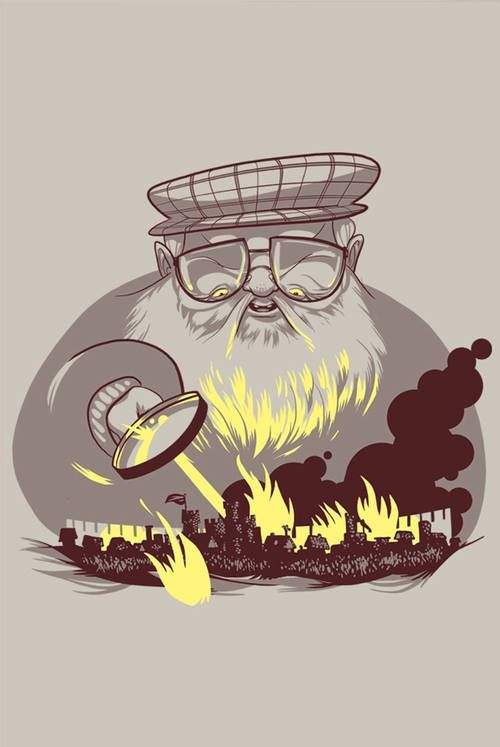

В данном задании вы будете работать с датасетом о персонажах из вселенной Игры Престолов [A Wiki of Ice and Fire](http://awoiaf.westeros.org/). Вам предстоит предсказать, кто из персонажей умрет, а кто останется вживых.



Описание данных:

* **name**: Имя персонажа

* **Title**: Социальный статус или знатность

* **House**: Дом, к которому принадлежит персонаж

* **Culture**: Социальная группа, к которой принадлежит персонаж

* **book1/2/3/4/5**: Появление персонажа в книге

* **Is noble**: Знатность персонажа, основанное на титуле

* **Age**: Отсчет времени: 305 AC

* **male**: Мужчина или женщина

* **dateOfBirth**: дата рождения

* **DateoFdeath**: дата смерти

* **Spouse**: Имя супруги\а персонажа

* **Father**: Имя отца персонажа

* **Mother**: Имя матери персонажа

* **Heir**: Имя наследника персонажа

* **Is married**: Состоит ли персонаж в браке

* **Is spouse alive**: Жив(а) ли супруг(а) персонажа

* **Is mother alive:** Жива ли мать персонажа

* **Is heir alive:** Жив ли наследник персонажа

* **Is father alive:** Указывает, жив ли отец персонажа

* **Number dead relations:** Количество умерших персонажей, с которыми персонаж связан

* **Popularity score:** Количество внутренних входящих и исходящих ссылок на страницу персонажей в вики http://awoiaf.westeros.org

Целевая переменная:
* **isAlive**: жив ли персонаж в книге

Оценивание:

Баллы считаются следующим образом:

1) $1.00 \geqslant score \geqslant 0.84$ --- 5 баллов

2) $0.84 > score \geqslant 0.77$ --- 4 балла

3) $0.77 > score \geqslant 0.70$ --- 3 балла

4) $0.70 > score \geqslant 0.65$ --- 2 балла

5) $0.65 > score \geqslant 0.6$ --- 1 балл

6) $0.60 > score$ --- 0 баллов

## Часть 1. Анализ и предобработка данных

Здесь вам необходимо сделать все шаги, которые обсуждались в первой части семинара.
* Предобработка данных
  * Обработка пропущенных данных
  * Создание новых признаков
  * Удаление ненужных столбцов
* Анализ данных
  * Анализ целевой переменной
  * Анализ признаков
  * Анализ влияния признаков на целевую переменную
* Подготовка данных для обучения модели

Загружаем датасет

In [1]:
!gdown 1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3 # test dataset
!gdown 1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v # train dataset

Downloading...
From: https://drive.google.com/uc?id=1h99toeF7lZ2I3iJwehgKO-QQmDaOe_O3
To: /content/game_of_thrones_test.csv
100% 37.3k/37.3k [00:00<00:00, 101MB/s]
Downloading...
From: https://drive.google.com/uc?id=1XL0VTygpZj-ZAuTNRBgApZTPQyNDnT-v
To: /content/game_of_thrones_train.csv
100% 138k/138k [00:00<00:00, 4.05MB/s]


**Задание 1.1.** Импортируйте библиотеки pandas, matplotlib, seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

**Задание 1.2.** Загрузите датасет в Pandas DataFrame при помощи функции `read_csv`. Вместо дефолтных наименований строк `0,1,...`, при помощи параметра `index_col`, сделайте значения колонки `S.No` наименованиями строк:

In [3]:
data = pd.read_csv('/content/game_of_thrones_train.csv', index_col='S.No')
data.head()

,name,title,male,culture,dateOfBirth,mother,father,heir,house,spouse,...,isAliveMother,isAliveFather,isAliveHeir,isAliveSpouse,isMarried,isNoble,age,numDeadRelations,popularity,isAlive
S.No,,,,,,,,,,,,,,,,,,,,,
1,Viserys II Targaryen,NaN,1,NaN,NaN,Rhaenyra Targaryen,Daemon Targaryen,Aegon IV Targaryen,NaN,NaN,...,1.0,0.0,0.0,NaN,0,0,NaN,11,0.605351,0
2,Walder Frey,Lord of the Crossing,1,Rivermen,208.0,NaN,NaN,NaN,House Frey,Perra Royce,...,NaN,NaN,NaN,1.0,1,1,97.0,1,0.896321,1
3,Addison Hill,Ser,1,NaN,NaN,NaN,NaN,NaN,House Swyft,NaN,...,NaN,NaN,NaN,NaN,0,1,NaN,0,0.267559,1
4,Aemma Arryn,Queen,0,NaN,82.0,NaN,NaN,NaN,House Arryn,Viserys I Targaryen,...,NaN,NaN,NaN,0.0,1,1,23.0,0,0.183946,0
5,Sylva Santagar,Greenstone,0,Dornish,276.0,NaN,NaN,NaN,House Santagar,Eldon Estermont,...,NaN,NaN,NaN,1.0,1,1,29.0,0,0.043478,1


**Задание 1.3.** Предобработка (очистка) данных.

Проанализируйте, если в колонках NaN значения. Если есть, примите решение, как вы их будете обрабатывать. Вы можете либо удалить их, либо заполнить каким нибудь значением (например, медианой или модой).

In [4]:
#в датасете 1557 строк
data.isna().sum(axis=0)

,0
name,0
title,840
male,0
culture,1069
dateOfBirth,1278
mother,1539
father,1535
heir,1536
house,381
spouse,1357


<BarContainer object of 25 artists>

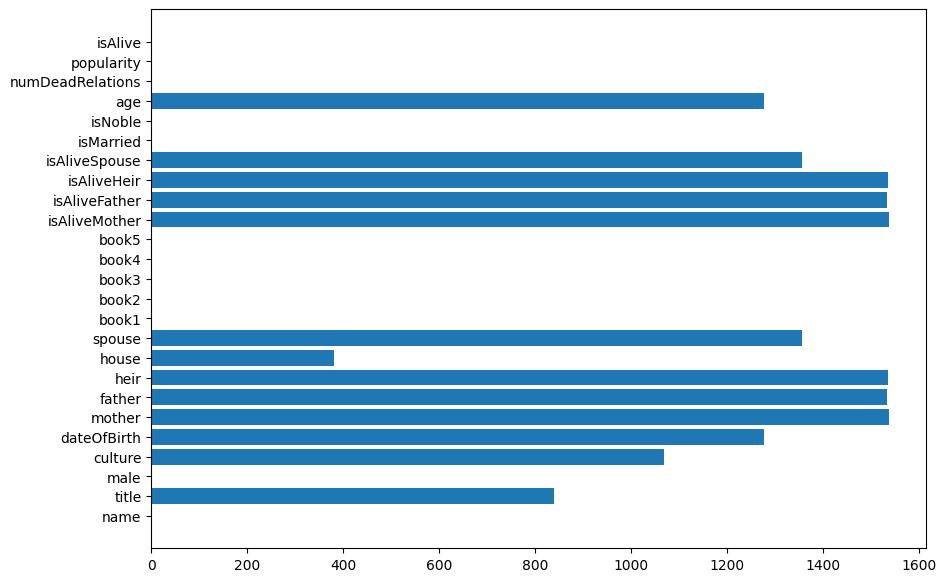

In [5]:
#визуализируем данные
nans = data.isna().sum()

plt.figure(figsize=(10,7))

plt.barh(nans.index, nans.values)

<Axes: xlabel='S.No'>

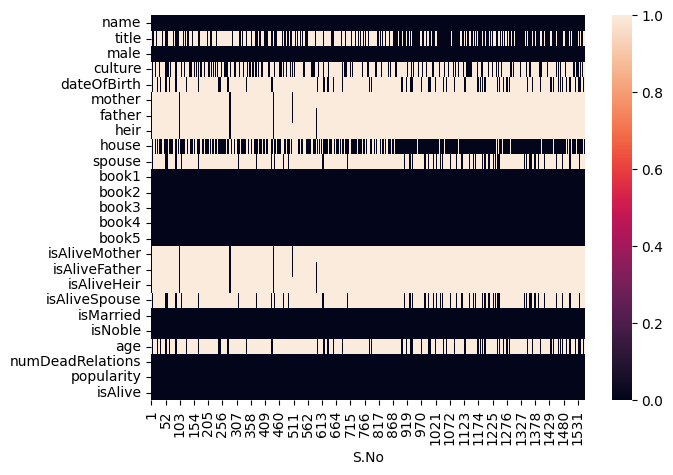

In [6]:
plt.figure(figsize=(7,5))
sns.heatmap(data.isna().transpose())

Дом можно попробовать восстановить по фамилии персонажа, добавив к ней префикс House:

In [7]:
def fill_house(row):
    if pd.isna(row['house']):
        last_name = row['name'].split()[-1]
        return f'House {last_name}'
    return row['house']

data['house'] = data.apply(fill_house, axis=1)

Далее посмотрим на признаки возраста, то есть сам возраст и дату рождения.

Age
Среднее = 35.29032258064516
Медиана = 24.0


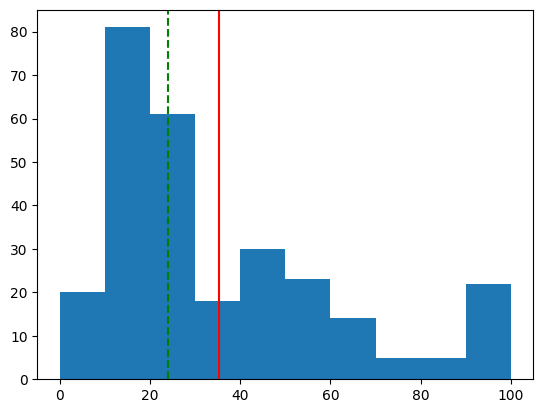

In [8]:
import numpy as np

print('Age')

mean_Age = np.mean(data['age'].dropna().values)
median_Age = np.quantile(data['age'].dropna().values,q=0.5)
print(f"Среднее = {mean_Age}")
print(f"Медиана = {median_Age}")

plt.hist(data['age'])

plt.axvline(x=mean_Age, color='r', linestyle = '-', label='mean')
plt.axvline(x=median_Age, color='g', linestyle = '--', label='median')

plt.show()

In [9]:
print('% пропусков возраста:', 100*data['age'].isna().sum()/len(data['age']))

% пропусков возраста: 82.08092485549133


Date of birth
Среднее = 247.55197132616487
Медиана = 272.0


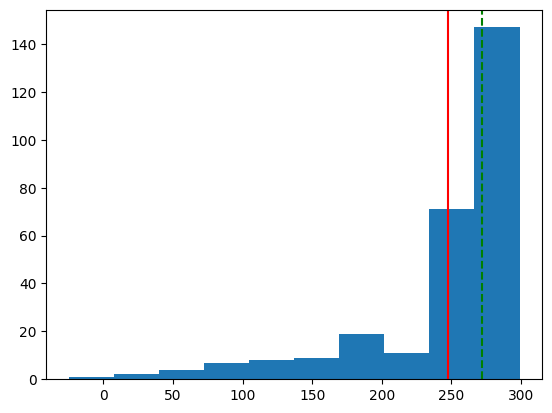

In [10]:
print('Date of birth')

mean_date = np.mean(data['dateOfBirth'].dropna().values)
median_date = np.quantile(data['dateOfBirth'].dropna().values,q=0.5)
print(f"Среднее = {mean_date}")
print(f"Медиана = {median_date}")

plt.hist(data['dateOfBirth'])

plt.axvline(x=mean_date, color='r', linestyle = '-', label='mean')
plt.axvline(x=median_date, color='g', linestyle = '--', label='median')

plt.show()

In [11]:
print('% пропусков даты рождения:', 100*data['dateOfBirth'].isna().sum()/len(data['dateOfBirth']))

% пропусков даты рождения: 82.08092485549133


У возраста и года рождения одиниковая доля пропусков, 82%. Запонять такое медианами - плохая идея, т.к. при этом сильно изменится распределение признаков. Заполню их значением -1.

В culture и title NaN'ов не так много, поэтому я заменю их на Other.
В признаках родственников персонажа, его брачного статуса, благородства, популярности и возраста NaN'ов очень много.

Можно удалить эти признаки, однако ниже я буду применять catboost, который может извлечь пользу даже из настолько разреженных признаков, поэтому заменю пропуски в них на -1.

In [12]:
data['culture'] = data['culture'].fillna('Other')
data['title'] = data['title'].fillna('Other')
for i in ['mother', 'father', 'heir', 'house', 'spouse']:
  data[i] = data[i].fillna('Other')

for i in ['dateOfBirth', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity']:
  data[i] = data[i].fillna(-1)

Дополнительно посмотрим на титулы, среди них есть много лордов и королей с избыточными уточнениями. Стоит их объединить с остальными королями и лордами. Там еще есть, что упрощать, но ограничусь пока этим.

In [13]:
data['title'].value_counts()

,count
title,
Other,840
Ser,306
Maester,29
Archmaester,21
Lord,19
...,...
Lord of Hellholt,1
Red Flower Vale,1
Lord of Harrenhal,1


In [14]:
data['title'].unique()

array(['Other', 'Lord of the Crossing', 'Ser', 'Queen', 'Greenstone',
       'Hand of the King', 'Archmaester', 'Maester', 'Khal', 'red hand',
       'Castellan', 'Seven Kingdoms', 'PrincessQueen',
       'Lord of the Iron Islands', 'Lord', 'Brother', 'Lord of Coldmoat',
       'Prince of Dragonstone', 'Lady', 'PrincessSepta', 'Princess',
       'Septa', 'Grand Maester', 'Septon', 'King', 'Seneschal',
       'Bloodrider', 'Stokeworth', 'Prince', 'LadyQueenDowager Queen',
       'Lord of the Tides', 'Lord of Dragonstone', 'Goodman', 'Wisdom',
       'King in the North', 'Winterfell', 'Steward', 'Eyrie',
       'Casterly Rock', 'Cupbearer', 'Hornwood',
       'Lord Steward of the Iron Islands', 'Blue Grace', 'Red Priest',
       'Khalakka', 'Good Master', 'QueenBlack Bride', 'Last Hearth',
       'Lord Paramount of the Mander', 'Seagard', 'Goodwife', 'Uplands',
       'BrotherProctor', 'Coldmoat', 'Ashford', 'Wind Witch', 'LadyQueen',
       'Broad Arch', 'Brightwater', 'Lady Marya', 'Bl

In [15]:
def title_simplifier(row):
  if row.startswith('Lord'):
    row = 'Lord'
  if row.startswith('King'):
    row = 'King'
  return row

In [16]:
data['title'] = data['title'].apply(lambda title: title_simplifier(title))

In [17]:
#проверим, все ли удалилось
data.isna().sum(axis=0)

,0
name,0
title,0
male,0
culture,0
dateOfBirth,0
mother,0
father,0
heir,0
house,0
spouse,0


Пустых значений больше нет, отлично.

**Задание 1.4.** Создайте новые признаки.
* Создайте признак isPopular. У вас есть в таблице признак popularity score, поставьте какой то порог, например, 0.5, и пусть те персонажи, у которых popularity score меньше 0.5, непопулярны, т.е. isPopular = 0. Если же выше 0.5, тогда пусть isPopular=1.
* Создайте признак boolDeadRelations. Давайте упростим признак numDeadRelations, и просто поделим людей на тех, у кого были хоть какие то отношения с мертвыми персонажами, т.е. numDeadRelations > 0, и те, у которых не было, т.е. numDeadRelations = 0.
* Упростите признак culture, объединив схожие названия в один.


In [18]:
def cult_simplifier(cult):
  # дополнил словарь значениями, которые есть в данных и тоже требуют упрощения
  compresscult = {
    'Summer Islands': ['summer islands', 'summer islander', 'summer isles'],
    'Ghiscari': ['ghiscari', 'ghiscaricari',  'ghis'],
    'Asshai': ["asshai'i", 'asshai'],
    'Lysene': ['lysene', 'lyseni'],
    'Andal': ['andal', 'andals'],
    'Braavosi': ['braavosi', 'braavos'],
    'Dornish': ['dornishmen', 'dorne', 'dornish'],
    'Myrish': ['myr', 'myrish', 'myrmen'],
    'Westermen': ['westermen', 'westerman', 'westerlands'],
    'Westerosi': ['westeros', 'westerosi'],
    'Stormlander': ['stormlands', 'stormlander'],
    'Norvoshi': ['norvos', 'norvoshi'],
    'Northmen': ['the north', 'northmen', 'northern mountain clans'],
    'Free Folk': ['wildling', 'first men', 'free folk'],
    'Qartheen': ['qartheen', 'qarth'],
    'Reach': ['the reach', 'reach', 'reachmen'],
    'Vale' : ['vale mountain clans', 'valemen'],
    'Free Cities' : ['qohor','tyroshi'],
    'Slaver Bay' :['meereenese', 'astapori'],
    'Ironborn':['ironmen', 'ironborn'],
    'Essos' : ['valyrian', 'dothraki']
  }
  for k, l in compresscult.items():
    if cult.lower() in l:
      cult = k
  return cult

data['isPopular'] = data['popularity'].apply(lambda x: 1 if x >= 0.5 else 0)
data['boolDeadRelations'] = data['numDeadRelations'].apply(lambda x: 1 if x > 0 else 0)
data['culture'] = data['culture'].apply(lambda cult: cult_simplifier(cult))

Может оказаться полезным еще один признак: совпадает ли сумма года рождения и возраста с 305 годом, когда зарегестрировали возрасты персонажей?

Если нет, то персонаж 100% мертв. Если да, то не факт, что он жив, потому что мы не знаем, на какой год собрали целевой признак isAlive.

Назову этот признак alive_305.

In [19]:
def alive_305_checker(row):
  if row['age'] + row['dateOfBirth'] == 305:
    return 1
  else:
    return 0

data['alive_305'] = data.apply(alive_305_checker, axis=1)

Значения домов в основном выглядят как 'House Xyz', однако некоторые из них в скобках и с маленькой буквы. Приведу их к общему виду.

In [20]:
def house_simplifier(x):
  if not x.startswith('House'):
    x = 'House ' + x
  h, x = x.split(' ', maxsplit=1)
  if x.endswith(')'):
    x = x[:-1]
  if x.startswith('('):
    x = x[1:]
  if x[0].islower():
    x = x[0].upper() + x[1:]
  return h + ' ' + x

data['house'] = data['house'].apply(lambda x: house_simplifier(x))

Для обучения полезно отмасштабировать численные данные. Это обычно делают через standartscaler, однако он не может обрабатывать строковые значения признаков.

Для catboost перевод строковых признаков в численные не нужен, поэтому для того, чтобы не делать две параллельных предобработки, я отмасштабирую признаки прямо в датафрейме самописным скейлером.

In [21]:
def my_scaler(data, mode='transform', meanstds=None):
  num_cols = ['dateOfBirth', 'numDeadRelations', 'popularity']
  if mode == 'fit': # собираем параметры и применяем их
    meanstds = {} # параметры для масштабирования: среднее и стандартное отклонение
    for i in num_cols:
      meanstds[i] = (data[i].mean(), data[i].std())
      data[i] = data[i].apply(lambda x: x - meanstds[i][0]/meanstds[i][1])
    return data, meanstds
  if mode == 'transform': # применяем уже собранные параметры
    for i in num_cols:
      data[i] = data[i].apply(lambda x: x - meanstds[i][0]/meanstds[i][1])
    return data

In [22]:
data, meanstds = my_scaler(data, mode='fit')

**Задание 1.5.** Проанализируйте, какие столбцы являются существенными и влияют на предсказание, а какие нет. Удалите ненужные столбцы по вашему мнению.

На результат не будет влиять имя персонажа, поэтому его можно удалить, тем более, дом из него я уже взял.

In [23]:
data.drop(columns=['name'], inplace = True)

In [24]:
catdata = data.copy() # это пойдет в катбуст

Для всех моделей, кроме катбуста, я удалю признаки про родственников, т.к. они очень разреженные и вряд ли другие модели смогут достать из них что-то полезное.

In [25]:
data.drop(columns=['mother', 'father', 'heir', 'spouse', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse'], inplace = True)

**Задание 1.6.** Проанализируйте целевую переменную. Посмотрите, является ли она категориальной или количественной. Так как мы говорим о задаче классификации, проанализируйте является ли датасет сбалансированным по классам или нет.

Целевая переменная isAlive - категориальная и принимает только два значения: 0 и 1.

In [26]:
data['isAlive'].value_counts()

,count
isAlive,
1,1212
0,345


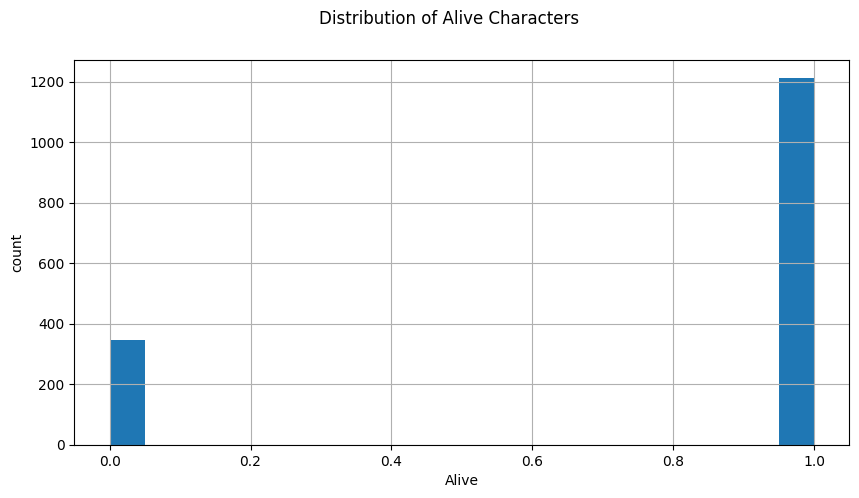

In [27]:
plt.figure(figsize = (10, 5))

data['isAlive'].hist(density=False, bins=20)
plt.ylabel('count')
plt.xlabel('Alive')

plt.suptitle('Distribution of Alive Characters')
plt.show()

Как видно, по целевому классу датасет не сбалансирован, живых персонажей примерно в 3 раза больше (77,8%).

**Задание 1.7.** Проанализируйте признаки.
  * Обработайте категориальные признаки и переведите их в числа. Можете выбрать любой кодировщик.
  * Проанализируйте количественные признаки. Есть ли корреляция между признаками?

У нас есть всего три категориальных признака, house, culture и title. Перед кодированием посмотрим на их уникальные значения.

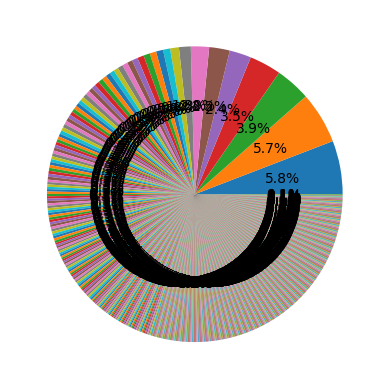

In [28]:
df_house = data['house'].value_counts()

#Строим круговую диаграмму
plt.pie(df_house, autopct='%1.1f%%')
plt.show()


В house очень много мелких домов.

А теперь - culture.

<ipython-input-29-2d2602fb4cd8>:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


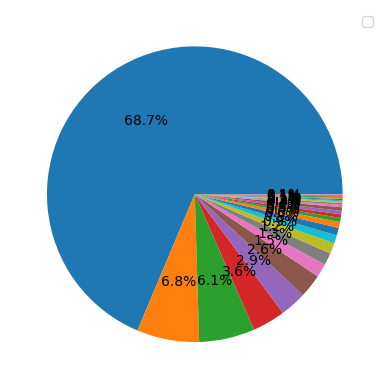

In [29]:
df_culture = data['culture'].value_counts()
plt.pie(df_culture, autopct='%1.1f%%')
plt.legend()
plt.show()

И титулы.

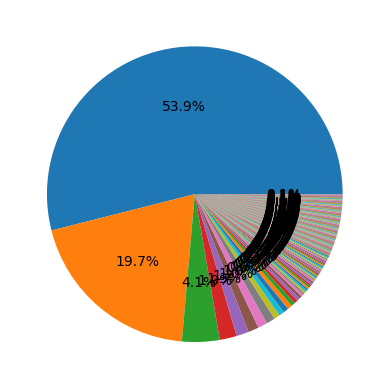

In [30]:
df_title = data['title'].value_counts()

#Строим круговую диаграмму
plt.pie(df_title, autopct='%1.1f%%')
plt.show()

Все эти признаки содержат много уникальных значений. Выделю редкие (встречаются менее 10 раз) в отдельный класс Rare для всех моделей, кроме катбуста, отделил его данные выше.

In [31]:
df_culture = data['culture'].value_counts()
df_house = data['house'].value_counts()
df_title = data['title'].value_counts()

In [32]:
all_houses = pd.unique(data['house'])
all_cultures = pd.unique(data['culture'])
all_titles = pd.unique(data['title'])

In [33]:
data['house'] = data['house'].apply(lambda x: 'Rare' if df_house[x] <= 10 else x)
remained_houses = pd.unique(data['house'])
rare_houses = [i for i in all_houses if i not in remained_houses]

In [34]:
data['culture'] = data['culture'].apply(lambda x: 'Rare' if df_culture[x] <= 10 else x)
remained_cultures = pd.unique(data['culture'])
rare_cultures = [i for i in all_cultures if i not in remained_cultures]

In [35]:
data['title'] = data['title'].apply(lambda x: 'Rare' if df_title[x] <= 10 else x)
remained_titles = pd.unique(data['title'])
rare_titles = [i for i in all_titles if i not in remained_titles]

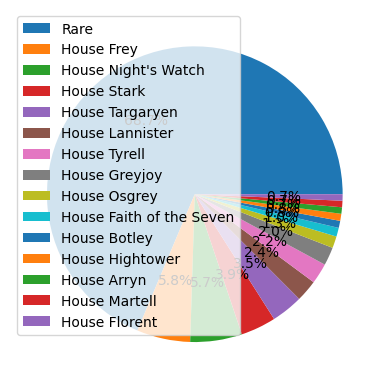

In [36]:
df_house1 = data['house'].value_counts()

#Строим круговую диаграмму
plt.pie(df_house1, autopct='%1.1f%%')
plt.legend(df_house1.index, loc = 'upper left')
plt.show()

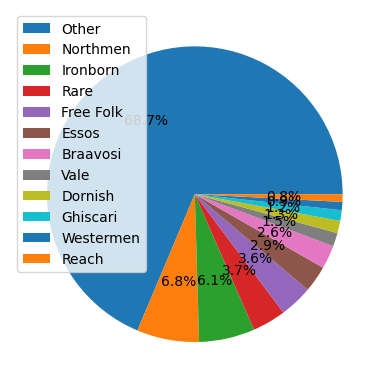

In [37]:
df_culture1 = data['culture'].value_counts()

#Строим круговую диаграмму
plt.pie(df_culture1, autopct='%1.1f%%')
plt.legend(df_culture1.index, loc = 'upper left')
plt.show()

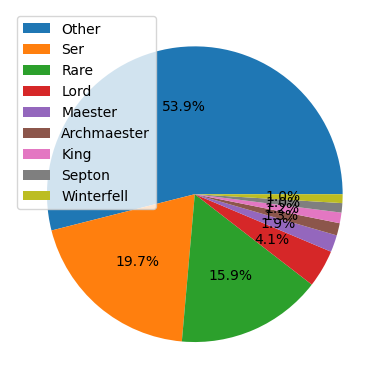

In [38]:
df_title1 = data['title'].value_counts()

#Строим круговую диаграмму
plt.pie(df_title1, autopct='%1.1f%%')
plt.legend(df_title1.index, loc = 'upper left')
plt.show()

Ситуация немного улучшилась, особенно в случае домов и титулов. Для кодирования этих признаков буду использовать one-hot энкодер, т.к label не рекомендуется использовать для кодирования признаков.

In [39]:
data.columns

Index(['title', 'male', 'culture', 'dateOfBirth', 'house', 'book1', 'book2',
       'book3', 'book4', 'book5', 'isMarried', 'isNoble', 'age',
       'numDeadRelations', 'popularity', 'isAlive', 'isPopular',
       'boolDeadRelations', 'alive_305'],
      dtype='object')

In [40]:
unprocessed_cat_features = ['house', 'culture', 'title']

In [41]:
from sklearn.preprocessing import OneHotEncoder

#Initialize OneHotEncoder
encoder = OneHotEncoder(sparse_output=False)

# Apply one-hot encoding to the categorical columns
one_hot_encoded = encoder.fit_transform(data[unprocessed_cat_features])

#Create a DataFrame with the one-hot encoded columns
#We use get_feature_names_out() to get the column names for the encoded data
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(unprocessed_cat_features), index=data.index
                          )
# Concatenate the one-hot encoded dataframe with the original dataframe
data = pd.concat([data, one_hot_df], axis=1)

# Drop the original categorical columns
data = data.drop(unprocessed_cat_features, axis=1)

Теперь проанализируем количественные признаки. Численных признаков у нас четыре: age, dateOfBirth, popularity, numDeadRelations. Посмотрим на их распределения.

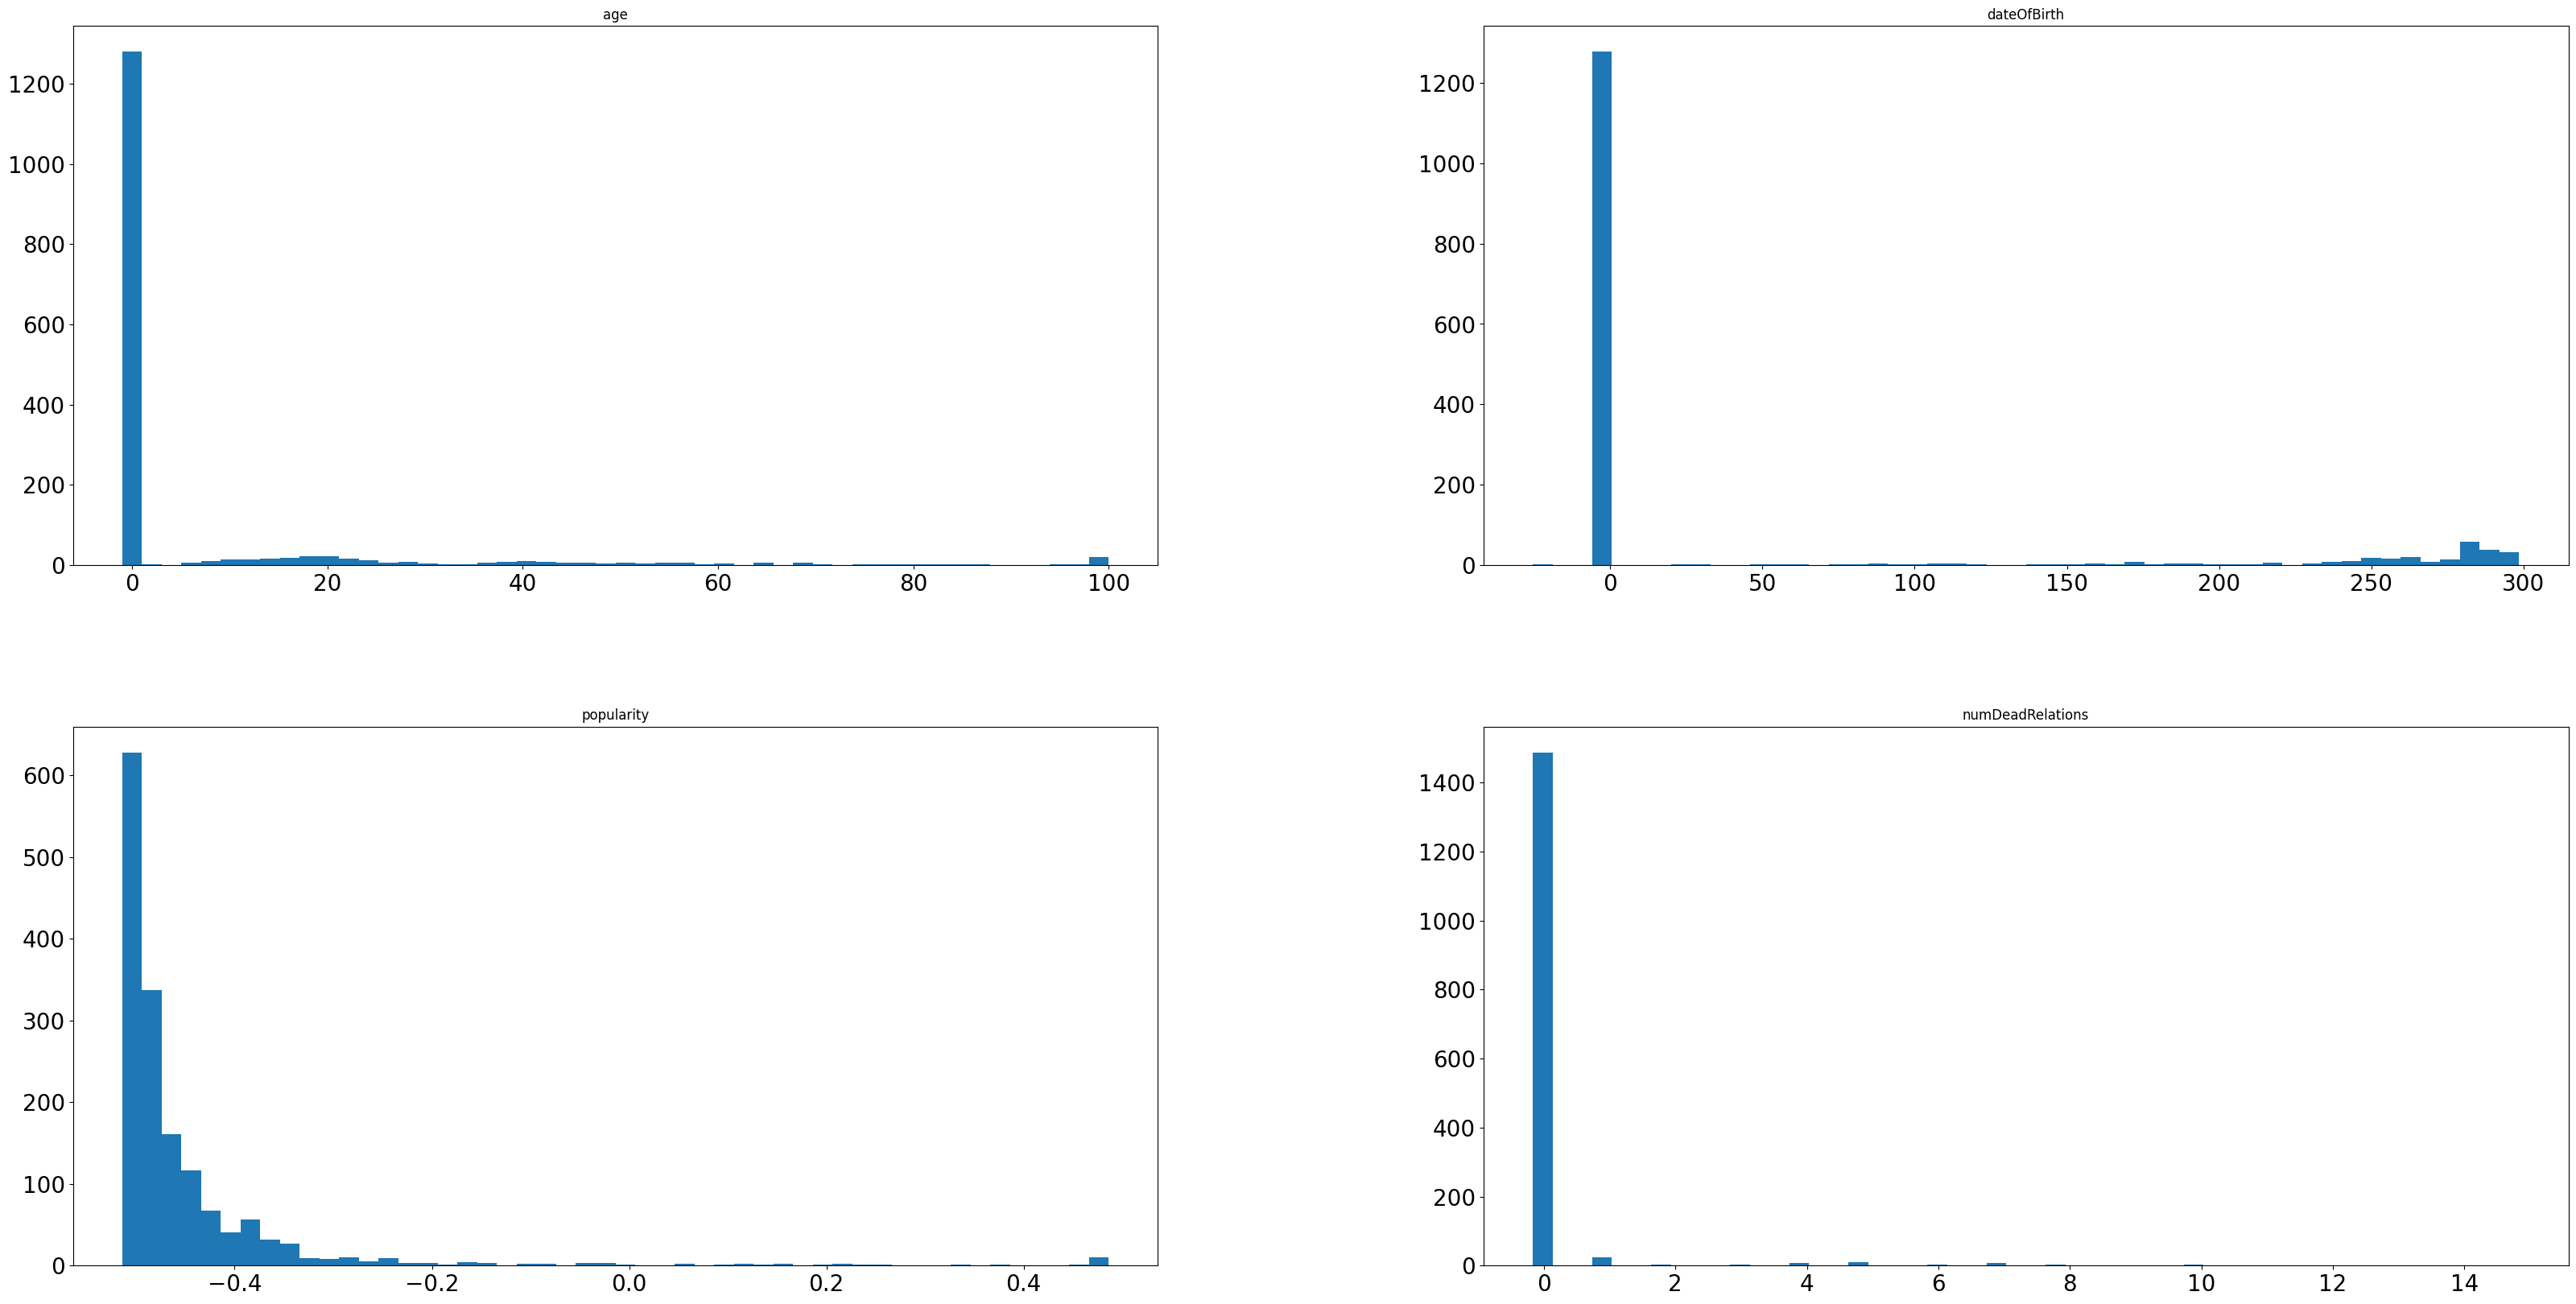

In [42]:
numerical_columns = ['age', 'dateOfBirth', 'popularity', 'numDeadRelations']
num_features = data[numerical_columns]
num_features.hist(figsize=(40, 20), bins=50, xlabelsize=20, ylabelsize=20, grid=False);

Возраст, дата рождения и число связей с мертвыми имеют очень большой перевес одного значения: -1 (на самом деле из-за нормировки там примерно -1,4 но это по сути и духу -1) или 0. Только у популярности есть заметное количество ненулевых значений, но и те отрицательные. Полагаю, это произошло из-за нормировки.

Также у нас есть несколко бинарных признаков: alive_305, isNoble, isMarried, boolDeadRelations, isPopular, male, book1-5.

Посмотрим, как количество персонажей распределено по книгам.

<BarContainer object of 5 artists>

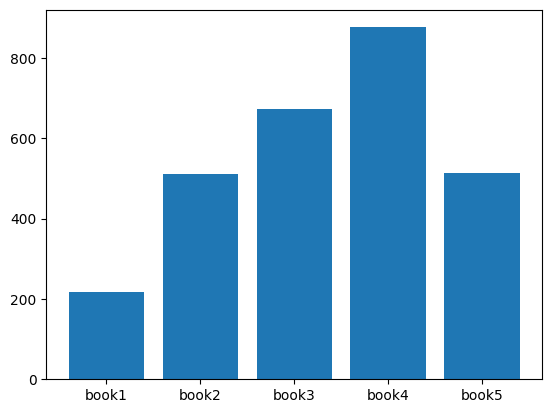

In [43]:
book_df = pd.DataFrame()
for s in ['book1', 'book2', 'book3', 'book4', 'book5']:
  book_df[s] = data[data[s] == 1][s].value_counts()
book_df.index.names = ['Index']
book_df = book_df.transpose()
#каждое значение в book_df почему-то запаковалось в список из одного элемента,
#поэтому я скопировал значения и удалил избыточную вложенность вручную
plt.bar(book_df.index, [216,510,672,876,514])

Как видим, во всех книгах разное количество персонажей, притом с 1 по 4 книги их число растет, а затем - падает. Далее посмотрим на остальные бинарные.

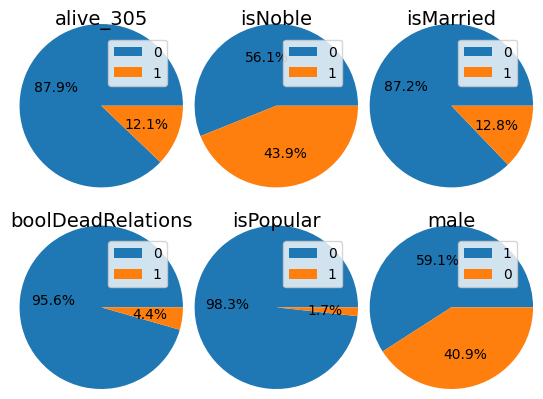

In [44]:
binars = ['alive_305', 'isNoble', 'isMarried', 'boolDeadRelations', 'isPopular', 'male']
j = 1

for i in binars:
  df = data[i].value_counts()
  ax = plt.subplot(2, 3, j)
  ax.set_title(f"{i}", fontsize=14)
  j += 1
  ax.pie(df, radius=1.4, autopct='%1.1f%%')
  ax.legend(df.index, loc = 'upper right')

plt.show()

Видим, что подавляющее большинство персонажей непопулярны и не имеют отношений с мертвыми. Живых на 305 год и состоящих в браке примерно в 9 раз меньше, чем мертвых и не стостоящих. Самая маленькая разница (60/40) в классах пола и багородства.

Посмотрим на корреляции всех признаков.

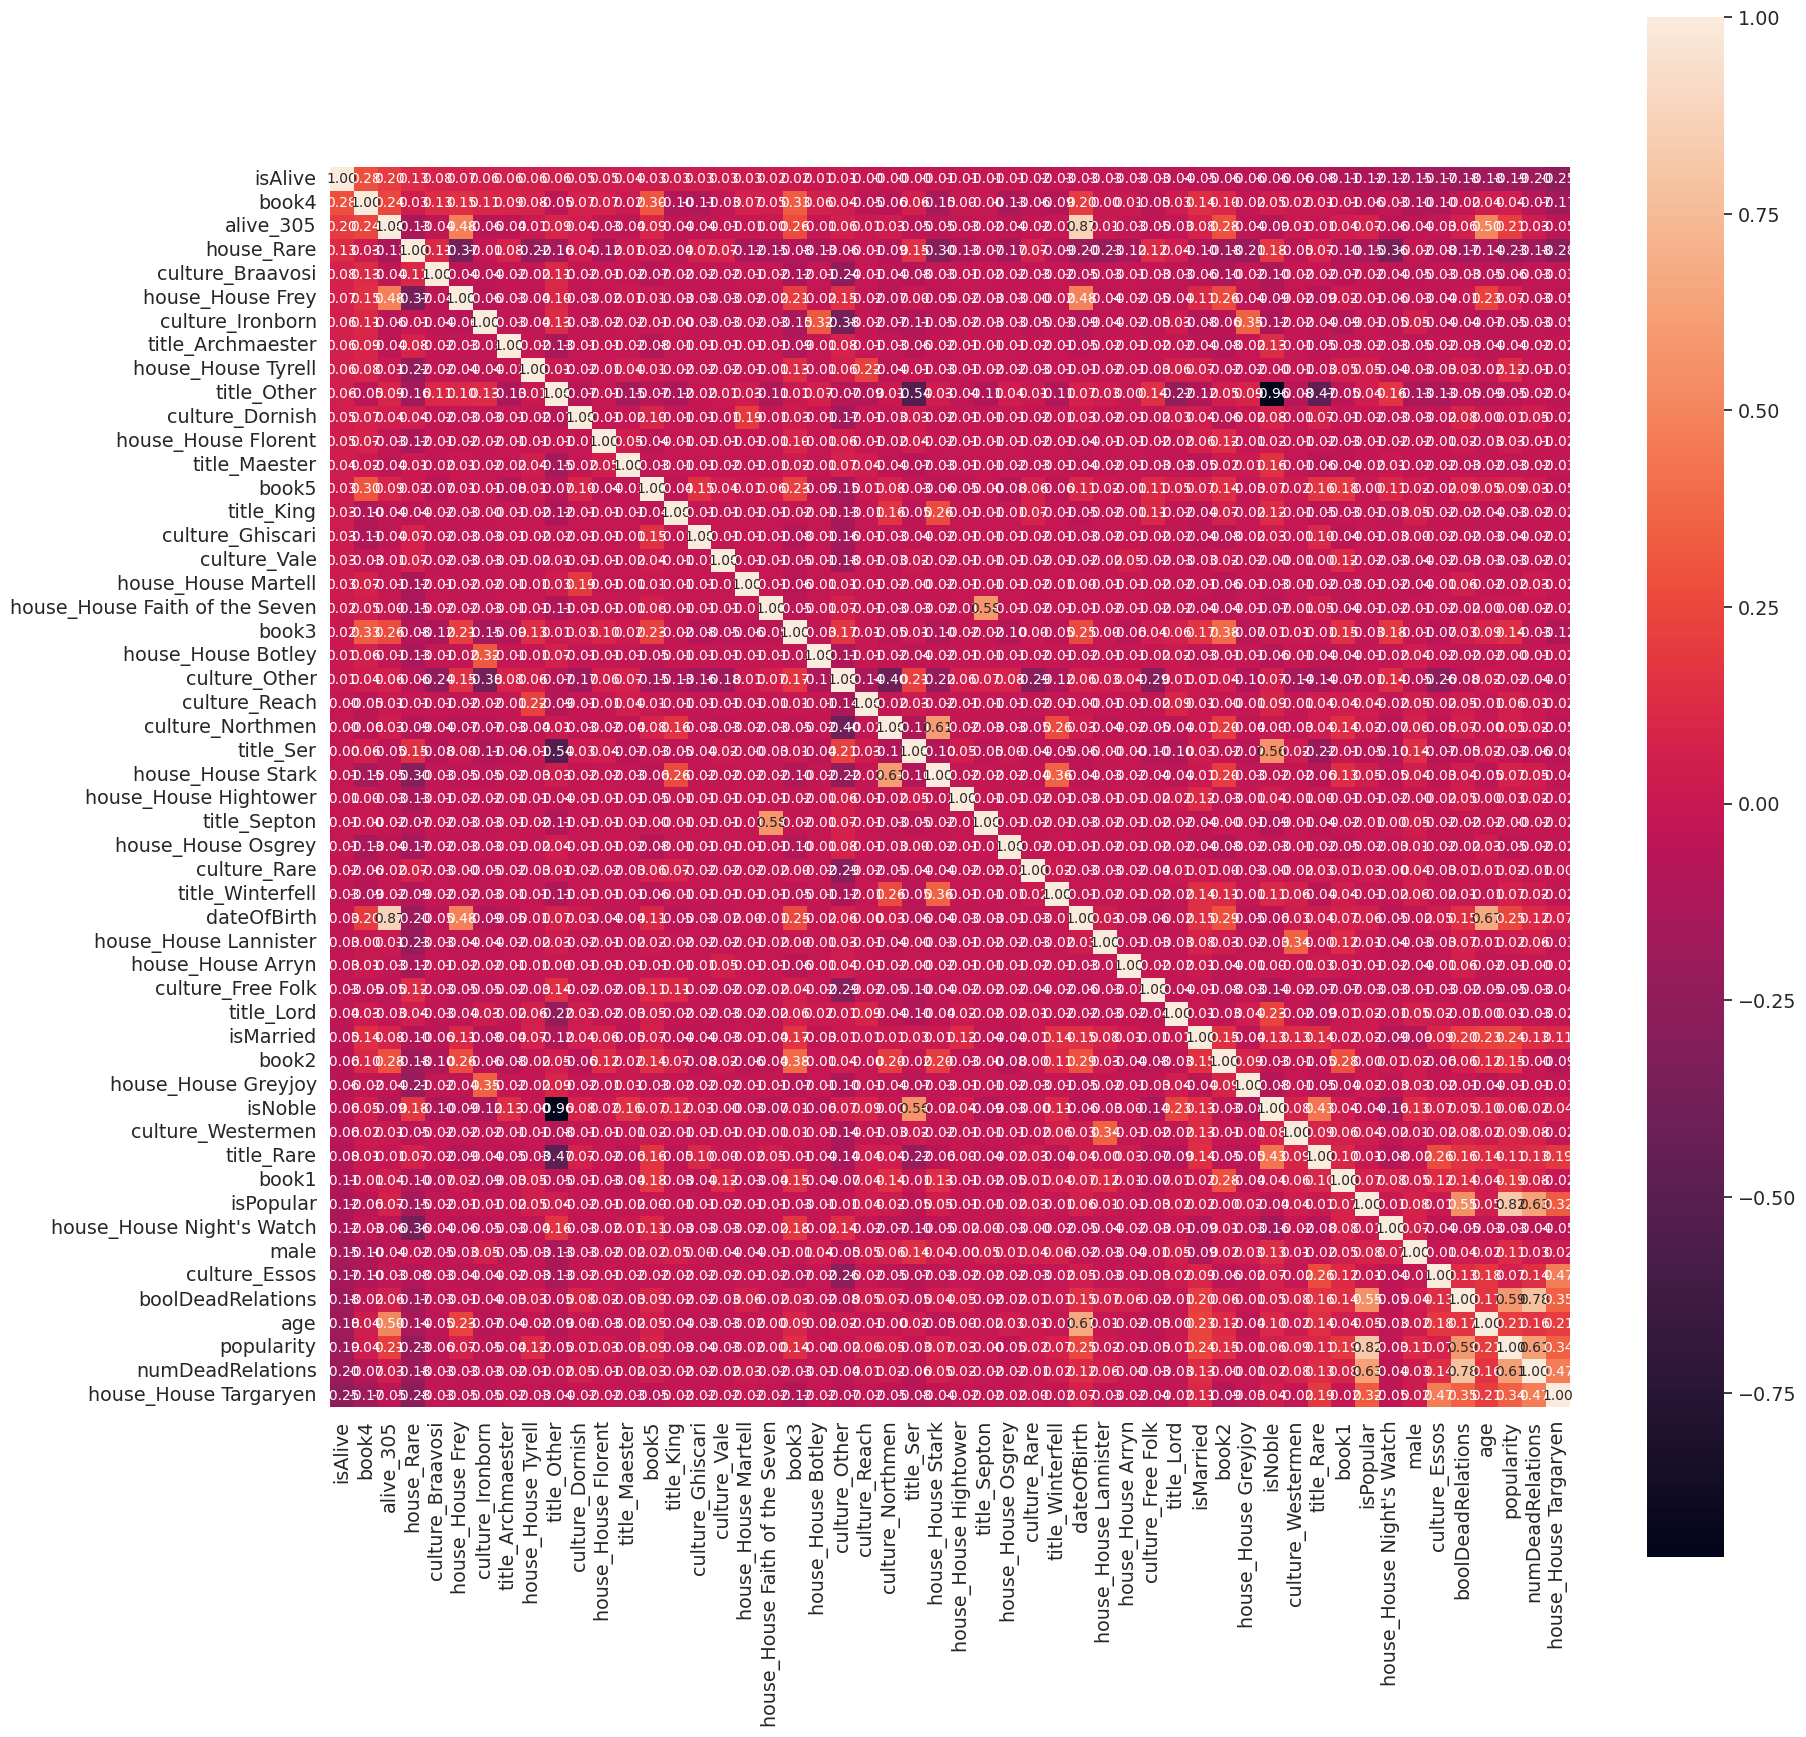

In [45]:
corrmat = data.corr()


k = 121 # number of variables for heatmap
cols = corrmat.nlargest(k, 'isAlive')['isAlive'].index
cm = np.corrcoef(data[cols].values.T)
sns.set(font_scale=1.25)
plt.figure(figsize=(20, 20))
hm = sns.heatmap(cm, cbar=True, annot=True, square=True, fmt='.2f', annot_kws={'size': 10}, yticklabels=cols.values, xticklabels=cols.values)
plt.show()

Можно заметить, что заметно (>= 0,50 по модулю) коррелируют или антикоррелируют house Stark и Northmen, титул сэра и благородство (что очевидно), неизвестный титул и багородство, дом веры семерых и титул септона, age, alive_305 и dateOfBirth, а также все признаки, связанные с популярностью и отношениями с мертвыми персонажами. Для устранения корреляций удалю popularity, dateOfBirth, title_other, title_ser, house_faith of the seven, age, boolDeadRelations и Northmen.



In [46]:
data.drop(columns=['dateOfBirth', 'culture_Northmen', 'boolDeadRelations', 'popularity', 'age', 'title_Other', 'title_Ser', 'house_House Faith of the Seven'], inplace = True)

**Задание 1.8.** Проанализируйте влияние признаков на целевую переменную.

In [47]:
# Определение количественных признаков
quantitative_columns = data.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Вычисление коэффициентов корреляции с целевой переменной
correlation_with_target = data[quantitative_columns].corr()['isAlive'].drop('isAlive')

# Вывод результатов
print("Корреляция нецелевых признаков с isAlive:")
print(correlation_with_target)

Корреляция нецелевых признаков с isAlive:
male                        -0.148290
book1                       -0.112468
book2                       -0.055998
book3                        0.018427
book4                        0.284014
book5                        0.032531
isMarried                   -0.049381
isNoble                     -0.060572
numDeadRelations            -0.198876
isPopular                   -0.118673
alive_305                    0.198311
house_House Arryn           -0.028852
house_House Botley           0.011653
house_House Florent          0.045004
house_House Frey             0.067003
house_House Greyjoy         -0.056803
house_House Hightower       -0.006031
house_House Lannister       -0.028445
house_House Martell          0.026540
house_House Night's Watch   -0.123900
house_House Osgrey          -0.007806
house_House Stark           -0.005666
house_House Targaryen       -0.253848
house_House Tyrell           0.060042
house_Rare                   0.126245
culture_

Много маленьких значений, посмотрим отдельно на те, что более 0,1.

In [48]:
correlation_with_target[abs(correlation_with_target) >= 0.1]

,isAlive
male,-0.148290
book1,-0.112468
book4,0.284014
numDeadRelations,-0.198876
isPopular,-0.118673
alive_305,0.198311
house_House Night's Watch,-0.123900
house_House Targaryen,-0.253848
house_Rare,0.126245
culture_Essos,-0.166424


Корреляции в основном низкие, кроме Таргариенов и 4-ой книги.

**Задание 1.9.** Создайте переменные `X`, которая будет хранить только значения признаков, и `y`, которая будет хранить только значения целевой переменной.

In [49]:
X = data.drop(columns=['isAlive']).values
y = data['isAlive'].values

catX = catdata.drop(columns=['isAlive']).values
caty = catdata['isAlive'].values

**Задание 1.10.** Разделите датасет на train и test часть при помощи функции `train_test_split`

In [50]:
from sklearn.model_selection import train_test_split

In [51]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)
catX_train, catX_test, caty_train, caty_test = train_test_split(catX, caty, test_size=0.2, shuffle=True)

## Часть 2. Обучение моделей

В данной части домашнего задания, мы хотим научиться обучать модели для задачи классификации на наших данных.

**Задание 2.1.** Импортируйте следующие модели из библиотеки `sklearn`
* LogisticRegression
* RandomForestClassifier
* AdaBoostClassifier
* GaussianProcessClassifier
* GaussianNB
* KNeighborsClassifier
* SVC
* DecisionTreeClassifier


В качестве примера, импортируем модель `LogisticRegression`

In [52]:
from sklearn.linear_model import LogisticRegression

In [53]:
from sklearn.ensemble import AdaBoostClassifier, RandomForestClassifier
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

**Задание 2.2.** Обучите модель и сделайте предсказание на тестовой выборке

В качестве примера, обучим модель `LogisticRegression` и сделаем на ней предсказания на тестовой выборке.

In [54]:
# Шаг 1. создание модели
logistic_regression = LogisticRegression(C=1)

# Шаг 2. обучение модели
logistic_regression.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)

In [55]:
#AdaBoost
# Шаг 1. создание модели
ada = AdaBoostClassifier(n_estimators=100, algorithm="SAMME", random_state=42)

# Шаг 2. обучение модели
ada.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred_ada = ada.predict(X_test)

/usr/local/lib/python3.11/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


In [56]:
#RandomForest
# Шаг 1. создание модели
rnf = RandomForestClassifier(max_depth=2, random_state=0)

# Шаг 2. обучение модели
rnf.fit(X_train, y_train)

# Шаг 3. Предсказание на тестовых данных
y_pred_rnf = rnf.predict(X_test)

In [57]:
#GaussianProcessClassifier
gpc = GaussianProcessClassifier(random_state=42)
gpc.fit(X_train, y_train)
y_pred_gpc = gpc.predict(X_test)

In [58]:
#GaussianNB
gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred_gnb = gnb.predict(X_test)

In [59]:
#KNeighborsClassifier
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

In [60]:
#SVC
svc = SVC(random_state=42)
svc.fit(X_train, y_train)
y_pred_svc = svc.predict(X_test)

In [61]:
#DecisionTreeClassifier(random_state=0)
dtc = DecisionTreeClassifier(random_state=42)
dtc.fit(X_train, y_train)
y_pred_dtc = dtc.predict(X_test)

Также обучу катбуст, спонсор максимальной точности.

In [62]:
!pip install catboost
from catboost import CatBoostClassifier

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 8.1 MB/s eta 0:00:00


In [63]:
# Catboost
# Явное указание категориальных признаков по номерам столбцов
cat_features = [0, 2, 4, 5, 6, 7, 8]



# Создание и обучение модели с указанием категориальных признаков
catmodel = CatBoostClassifier(iterations=1000, learning_rate=0.1, depth=6, verbose=500)
catmodel.fit(catX_train, caty_train, cat_features=cat_features)

# Оценка производительности модели
accuracy = catmodel.score(catX_test, caty_test)
print(f"Accuracy: {accuracy}")

0:	learn: 0.6219628	total: 71.1ms	remaining: 1m 10s
500:	learn: 0.0951423	total: 2.81s	remaining: 2.8s
999:	learn: 0.0480159	total: 6.12s	remaining: 0us
Accuracy: 0.8525641025641025


## Часть 3. Оцените качество моделей

Вам необходимо познакомиться с метриками задачи классификации из sklearn. Оцените все модели и выберите лучшую по метрике качества Accuracy.

С метриками классификации вы можете ознакомиться в [Yandex ML Book](https://education.yandex.ru/handbook/ml/article/metriki-klassifikacii-i-regressii).

Для простоты в данном домашнем задании мы будем работать с самой базовой метрикой для задачи классификации - accuracy.

**Задание 3.1.** Вам необходимо посчитать метрику для всех моделей и выбрать лучшую модель.

Сначала импортируем необходимую функцию из библиотеки sklearn для подсчета accuracy.

In [64]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import make_scorer

In [65]:
accuracies = {}

In [66]:
# Шаг 3. Предсказание на тестовых данных
y_pred = logistic_regression.predict(X_test)
y_train_pred = logistic_regression.predict(X_train)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy_train = accuracy_score(y_train, y_train_pred)
print("Accuracy train : %.4f" % accuracy_train)
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy : %.4f" % accuracy)

accuracies['logistic_regression'] = (accuracy_train, accuracy)

Accuracy train : 0.8072
Accuracy : 0.8429


Аналогичным образом посчитайте метрику accuracy для остальных моделей

Для обнаружения переобучения добавил точность моделей на тренировочном сете.

In [67]:
#AdaBoost
# Шаг 3. Предсказание на тестовых данных
y_pred_ada = ada.predict(X_test)
y_train_pred_ada = ada.predict(X_train)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy_train_ada = accuracy_score(y_train, y_train_pred_ada)
print("Accuracy train : %.4f" % accuracy_train_ada)

accuracy = accuracy_score(y_test, y_pred_ada)
print("Accuracy : %.4f" % accuracy)

accuracies['ada'] = (accuracy_train_ada, accuracy)

Accuracy train : 0.8040
Accuracy : 0.8494


In [68]:
#RandomForest
# Шаг 3. Предсказание на тестовых данных
y_pred_rnf = rnf.predict(X_test)
y_train_pred_rnf = rnf.predict(X_train)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy_train_rnf = accuracy_score(y_train, y_train_pred_rnf)
print("Accuracy train : %.4f" % accuracy_train_rnf)

accuracy = accuracy_score(y_test, y_pred_rnf)
print("Accuracy : %.4f" % accuracy)

accuracies['random_forest'] = (accuracy_train_rnf, accuracy)

Accuracy train : 0.7823
Accuracy : 0.8205


In [69]:
#GaussianProcessClassifier
# Шаг 3. Предсказание на тестовых данных
y_pred_gpc = gpc.predict(X_test)

y_train_pred_gpc = gpc.predict(X_train)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy_train_gpc = accuracy_score(y_train, y_train_pred_gpc)
print("Accuracy train : %.4f" % accuracy_train_gpc)

accuracy = accuracy_score(y_test, y_pred_gpc)

print("Accuracy : %.4f" % accuracy)

accuracies['GaussianProcessClassifier'] = (accuracy_train_gpc, accuracy)

Accuracy train : 0.8442
Accuracy : 0.8558


In [70]:
#GaussianNB
# Шаг 3. Предсказание на тестовых данных
y_pred_gnb = gpc.predict(X_test)

y_train_pred_gnb = gnb.predict(X_train)

# Шаг 4. Оценка предсказания по метрике accuracy
accuracy_train_gnb = accuracy_score(y_train, y_train_pred_gnb)
print("Accuracy train : %.4f" % accuracy_train_gnb)

accuracy = accuracy_score(y_test, y_pred_gnb)

print("Accuracy : %.4f" % accuracy)

accuracies['GaussianNB'] = (accuracy_train_gnb, accuracy)

Accuracy train : 0.4538
Accuracy : 0.8558


In [71]:
#KNeighborsClassifier
y_pred_knn = knn.predict(X_test)

y_train_pred_knn = knn.predict(X_train)

accuracy_train_knn = accuracy_score(y_train, y_train_pred_knn)
print("Accuracy train : %.4f" % accuracy_train_knn)
accuracy = accuracy_score(y_test, y_pred_knn)

print("Accuracy : %.4f" % accuracy)

accuracies['knn'] = (accuracy_train_knn, accuracy)

Accuracy train : 0.8538
Accuracy : 0.8077


In [72]:
#SVC
y_pred_svc = svc.predict(X_test)
y_train_pred_svc = svc.predict(X_train)

accuracy_train_svc = accuracy_score(y_train, y_train_pred_svc)
print("Accuracy train : %.4f" % accuracy_train_svc)

accuracy = accuracy_score(y_test, y_pred_svc)
print("Accuracy : %.4f" % accuracy)

accuracies['svc'] = (accuracy_train_svc, accuracy)

Accuracy train : 0.8209
Accuracy : 0.8462


In [73]:
#DecisionTreeClassifier
y_pred_dtc = dtc.predict(X_test)
y_train_pred_dtc = dtc.predict(X_train)

accuracy_train_dtc = accuracy_score(y_train, y_train_pred_dtc)
print("Accuracy train : %.4f" % accuracy_train_dtc)


accuracy = accuracy_score(y_test, y_pred_dtc)
print("Accuracy : %.4f" % accuracy)

accuracies['tree'] = (accuracy_train_dtc, accuracy)

Accuracy train : 0.9068
Accuracy : 0.7917


In [74]:
accuracy_train_cat = catmodel.score(catX_train, caty_train)
print("Accuracy train : %.4f" % accuracy_train_cat)


accuracy = catmodel.score(catX_test, caty_test)
print("Accuracy: %.4f" % accuracy)

accuracies['catboost'] = (accuracy_train_cat, accuracy)

Accuracy train : 0.8996
Accuracy: 0.8526


Соберу все числа в одном месте для удобства.

In [75]:
for i in accuracies:
  print(i)
  print(f'train_accuracy: {accuracies[i][0]}')
  print(f'valid_accuracy: {accuracies[i][1]}')
  print()

logistic_regression
train_accuracy: 0.8072289156626506
valid_accuracy: 0.842948717948718

ada
train_accuracy: 0.8040160642570281
valid_accuracy: 0.8493589743589743

random_forest
train_accuracy: 0.7823293172690763
valid_accuracy: 0.8205128205128205

GaussianProcessClassifier
train_accuracy: 0.8441767068273093
valid_accuracy: 0.8557692307692307

GaussianNB
train_accuracy: 0.4538152610441767
valid_accuracy: 0.8557692307692307

knn
train_accuracy: 0.8538152610441767
valid_accuracy: 0.8076923076923077

svc
train_accuracy: 0.8208835341365461
valid_accuracy: 0.8461538461538461

tree
train_accuracy: 0.9068273092369478
valid_accuracy: 0.7916666666666666

catboost
train_accuracy: 0.8995983935742972
valid_accuracy: 0.8525641025641025



Выберите лучшую модель.

Лучше всех себя показал catboost. При перезапусках блокнота другие модель могут оказаться более точными на валидации, но при проверке на степике их результаты всегда хуже catboost.

### Файл `submission.csv`

Вам нужно вместо значений в `submission.csv` файле в колонке `isAlive`, подставить свои предсказания и сохранить измененный файл.

In [76]:
!gdown 1M14conWjAW2QLoyCXbHEAy8bql2f99eF

Downloading...
From: https://drive.google.com/uc?id=1M14conWjAW2QLoyCXbHEAy8bql2f99eF
To: /content/submission.csv
100% 2.74k/2.74k [00:00<00:00, 11.7MB/s]


In [77]:
submission = pd.read_csv("/content/submission.csv", index_col='S.No')

In [78]:
data_test = pd.read_csv("/content/game_of_thrones_test.csv", index_col='S.No')

In [79]:
# общая предобработка
data_test['house'] = data_test.apply(fill_house, axis=1)
data_test['culture'] = data_test['culture'].fillna('Other')
data_test['title'] = data_test['title'].fillna('Other')
data_test.drop(columns=['name'], inplace = True)

for i in ['mother', 'father', 'heir', 'house', 'spouse']:
  data_test[i] = data_test[i].fillna('Other')

for i in ['dateOfBirth', 'isAliveMother', 'isAliveFather', 'isAliveHeir', 'isAliveSpouse',
       'isMarried', 'isNoble', 'age', 'numDeadRelations', 'popularity']:
  data_test[i] = data_test[i].fillna(-1)

data_test['title'] = data_test['title'].apply(lambda title: title_simplifier(title))
data_test['age'] = data_test['age'].fillna(-1)
data_test['dateOfBirth'] = data_test['dateOfBirth'].fillna(-1)
data_test['isPopular'] = data_test['popularity'].apply(lambda x: 1 if x >= 0.5 else 0)
data_test['boolDeadRelations'] = data_test['numDeadRelations'].apply(lambda x: 1 if x > 0 else 0)
data_test['culture'] = data_test['culture'].apply(lambda cult: cult_simplifier(cult))
data_test['alive_305'] = data_test.apply(alive_305_checker, axis=1)
data_test = my_scaler(data_test, mode='transform', meanstds=meanstds)

catdata_test = data_test.copy()

In [80]:
# предобработка для всех моделей, кроме катбуста
data_test.drop(columns=['mother', 'father', 'heir', 'spouse', 'isAliveMother', 'isAliveFather', 'isAliveHeir',
       'isAliveSpouse'], inplace = True)
data_test.drop(columns=['dateOfBirth', 'boolDeadRelations', 'popularity', 'age'], inplace = True)


data_test['house'] = data_test['house'].apply(lambda x: 'Rare' if x in rare_houses else x)
#логика отличается из-за заполнения домов фамилиями, энкодер не знает, что такое Other, придется записать их в Rare
data_test['house'] = data_test['house'].apply(lambda x: 'Rare' if x not in remained_houses else x)


data_test['culture'] = data_test['culture'].apply(lambda x: 'Rare' if x in rare_cultures else x)
data_test['culture'] = data_test['culture'].apply(lambda x: 'Other' if x not in remained_cultures else x)

data_test['title'] = data_test['title'].apply(lambda x: 'Rare' if x in rare_titles else x)
data_test['title'] = data_test['title'].apply(lambda x: 'Other' if x not in remained_titles else x)


unprocessed_cat_features = ['house', 'culture', 'title']
# Apply one-hot encoding to the categorical columns
one_hot_encoded = encoder.transform(data_test[unprocessed_cat_features])
one_hot_df = pd.DataFrame(one_hot_encoded, columns=encoder.get_feature_names_out(unprocessed_cat_features), index=data_test.index)
# Concatenate the one-hot encoded dataframe with the original dataframe
data_test = pd.concat([data_test, one_hot_df], axis=1)

# Drop the original categorical columns
data_test = data_test.drop(unprocessed_cat_features, axis=1)


todrop = ['culture_Northmen', 'title_Other', 'title_Ser', 'house_House Faith of the Seven']

for s in todrop:
  if s in list(data_test.columns):
    data_test.drop(columns=[s], inplace = True)

In [81]:
X_test = data_test.values
catX_test = catdata_test.values

Предсказываем лучшей моделью - catboost:

In [82]:
submission['isAlive'] = catmodel.predict(catX_test)

Как сохранить измененный Pandas DataFrame в csv файл:

In [83]:
submission.to_csv("/content/new_submission.csv", index='S.No')

In [84]:
from google.colab import files

files.download('/content/new_submission.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Результат на степике: 0.789